# ???? Project ??? Titanic with Gradient Boosting (End-to-End)

> **MLCourse ?? Machine Learning ?? supervised ?? classification**

### Business question
Same survival question as earlier modules ??? can sequentially-corrected trees
beat our logistic/forest baselines on the real passenger CSV?

End-to-end: load ??? EDA ??? processing ??? staged tuning ??? evaluation.

In [1]:
%matplotlib inline
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent

def get_data(fname, url):
    f = ML_ROOT / "data" / fname
    if not f.exists():
        f.write_bytes(urllib.request.urlopen(url).read())
        print("downloaded ->", fname)
    else:
        print("using local ->", fname)
    return pd.read_csv(f)

### 2. Data loading


In [2]:
df = get_data(
    "titanic.csv",
    "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv",
)
num_cols = [c for c in ["pclass", "age", "sibsp", "siblings_spouses_aboard",
                        "parch", "parents_children_aboard", "fare"] if c in df]
cat_cols = [c for c in ["sex", "embarked", "embark_town"] if c in df]

using local -> titanic.csv


### 3. Exploratory Data Analysis


missing:
 pclass           0
age            177
sibsp            0
parch            0
fare             0
sex              0
embarked         2
embark_town      2
dtype: int64


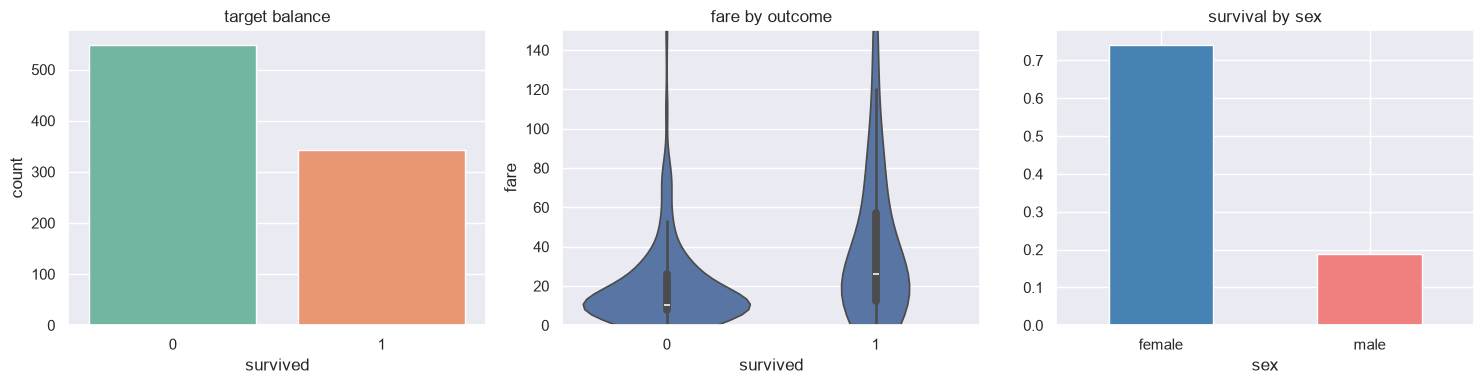

In [3]:
print("missing:\n", df[num_cols + cat_cols].isna().sum())
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(x="survived", data=df, ax=axes[0],
              palette="Set2", hue="survived", legend=False)
axes[0].set_title("target balance")
sns.violinplot(data=df, x="survived", y="fare", cut=0, ax=axes[1])
axes[1].set_ylim(0, 150); axes[1].set_title("fare by outcome")
if "sex" in cat_cols:
    df.assign(surv=df.survived).groupby("sex")["survived"].mean() \
      .plot(kind="bar", color=["steelblue", "lightcoral"], ax=axes[2])
    axes[2].set_title("survival by sex"); axes[2].tick_params(rotation=0)
plt.tight_layout(); plt.show()

### 4. Data processing


In [4]:
work = df[num_cols + cat_cols + ["survived"]].copy()
for c in num_cols:
    work[c] = work[c].fillna(work[c].median())
for c in cat_cols:
    work[c] = work[c].fillna(work[c].mode()[0])

X = pd.get_dummies(work[cat_cols + num_cols], drop_first=True)
y = work["survived"].values
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.25,
                                          random_state=42, stratify=y)

### 5. Model training ??? lr ?? depth grid with staged curves


best: {'learning_rate': 0.08, 'max_depth': 3} | CV 0.8369
test acc: 0.8072


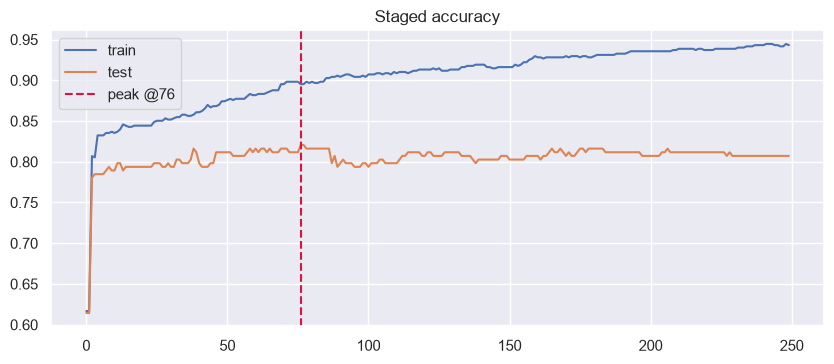

,pred died,pred survived
true died,121,16
true survived,27,59


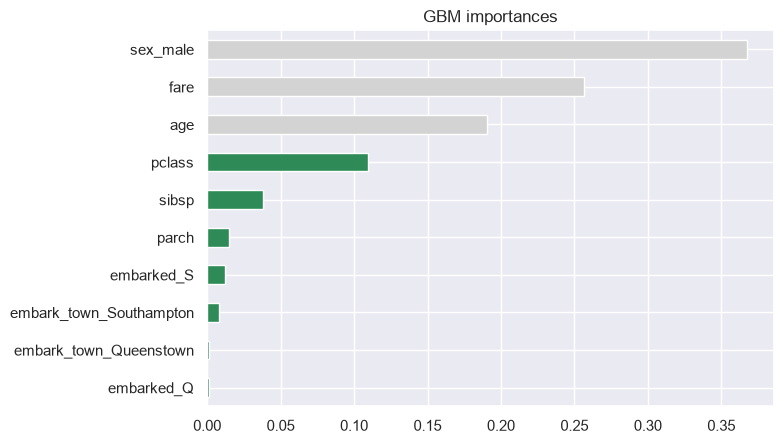

In [5]:
grid = GridSearchCV(
    GradientBoostingClassifier(n_estimators=250, subsample=0.8,
                               random_state=42),
    {"learning_rate": [0.03, 0.08],
     "max_depth": [2, 3]},
    cv=5, n_jobs=-1)
grid.fit(X_tr, y_tr)
best = grid.best_estimator_
pred = best.predict(X_te)

print("best:", grid.best_params_, f"| CV {grid.best_score_:.4f}")
print(f"test acc: {accuracy_score(y_te, pred):.4f}")

from sklearn.metrics import accuracy_score as _acc
st_tr = [_acc(y_tr, (p[:, 1] >= .5).astype(int)) for p in best.staged_predict_proba(X_tr)]
st_te = [_acc(y_te, (p[:, 1] >= .5).astype(int)) for p in best.staged_predict_proba(X_te)]
peak = int(np.argmax(st_te))
plt.figure(figsize=(8.5, 3.8))
plt.plot(st_tr, label="train"); plt.plot(st_te, label="test")
plt.axvline(peak, ls="--", c="crimson", label=f"peak @{peak}")
plt.legend(); plt.title("Staged accuracy"); plt.tight_layout(); plt.show()

display(pd.DataFrame(confusion_matrix(y_te, pred),
                     index=["true died", "true survived"],
                     columns=["pred died", "true survived" and "pred survived"]))

imp = pd.Series(best.feature_importances_, index=X.columns).sort_values()
colors = ["seagreen" if v > .01 else "lightgray" for v in imp]
imp.plot(kind="barh", color=colors[-len(imp):][::-1], figsize=(8, 4.6))
plt.title("GBM importances"); plt.tight_layout(); plt.show()

### 6. Findings

1. ~80???82% accuracy ??? a point or two over logistic/NB baselines; sex, fare,
     and age carry the ensemble.
2. Staged curve peaks early (~60???120 rounds): lower lr or fewer trees would
     match with less compute.
3. Importances align with every previous module's story.

### Takeaway
GBM's edge shows on harder data; here it matches RF at similar cost.